# 2 · Reaching the steady state, with and without a flip-angle ramp

Every equation of the paper (Eqs. 1–7) describes the **steady state**. A scan, and a simulation,
starts from thermal equilibrium instead, so dummy TRs have to be played before the first
phase-encoding line. This notebook measures how many, and whether ramping up the flip angle over
the first TRs shortens the wait.

Near resonance the SSFP transient has two parts ([Scheffler 2003](https://doi.org/10.1002/mrm.10421)):
an oscillation that is damped within a few $T_2$-weighted cycles, and a slow, non-oscillating
approach of the magnetisation magnitude with the rate

$$
\lambda=\cos^2(\alpha/2)/T_1+\sin^2(\alpha/2)/T_2 .
$$

A linear flip-angle ramp ([Deshpande et al. 2003](https://doi.org/10.1002/mrm.10337)) removes the
oscillation, but it cannot change $\lambda$. Long-$T_1$ fluid is the bottleneck: for CSF (Table S1:
$T_1=4.16$ s, $T_2=1.65$ s) at $\alpha=50°$ the time constant $1/\lambda$ is more than three seconds.

The simulations use [MR-zero](https://github.com/MRsources/MRzero-Core), which reads the same
`.seq` files that are played on the scanner. The probes below take about ten minutes on a GPU;
results are cached in `.cache/`.

In [1]:
import sys
import warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore", module="cupy|sigpy")

import numpy as np
import matplotlib.pyplot as plt
import pypulseq as pp
import mess
from mess import plotting, simulation as sim, theory

plotting.use_style()
CACHE = ".cache"

protocol = mess.MESS2D(orders=(2, -3), flip_angle=50)      # the protocol of notebook 1
alpha = np.deg2rad(protocol.flip_angle)
print(protocol)
print("\ntissue   T1 [s]  T2 [s]   1/lambda [s]   1/lambda [TR]")
for name in ("WM", "GM", "CSF"):
    _, t1, t2, _ = sim.TABLE_S1[name]
    lam = np.cos(alpha / 2) ** 2 / t1 + np.sin(alpha / 2) ** 2 / t2
    print(f"{name:6s} {t1:7.2f} {t2:7.3f} {1 / lam:12.2f} {1 / lam / protocol.tr:14.0f}")

MESS2D  orders [2, 1, 0, -1, -2, -3]
  readout moments (G1, G2, G3) = (-5, +12, -5) x u,  u = 375.0 1/m
  flip angle 50 deg   TR 10.040 ms   TE_0 4.644 ms   delta TE 0.750 ms
  TE_k [ms]: k=+2: 3.145  k=+1: 3.895  k=+0: 4.644  k=-1: 5.394  k=-2: 6.145  k=-3: 6.895
  matrix 150 x 150   FOV 200 x 200 x 5 mm   scan time 1.5 s (+ dummies)

tissue   T1 [s]  T2 [s]   1/lambda [s]   1/lambda [TR]
WM        0.83   0.075         0.30             30
GM        1.56   0.083         0.37             37
CSF       4.16   1.650         3.27            326


## A probe that follows the transient

The probe phantom is a row of isolated voxels of one tissue, at off-resonance $\Delta f=0$ and
$\Delta f=1/(4\text{TR})$. It is scanned with a one-line version of the protocol (same TR and TE, no
phase encoding) whose ADC is switched on every tenth TR: a 1D FFT of each recorded readout returns
the echoes of every voxel, so the approach to the steady state can be followed TR by TR.

The schedule is assembled from single repetitions with `protocol.add_tr`, the building block of
`make_sequence`; `mess.flip_angle_ramp(30)` gives the flip-angle scale of a 30-TR linear ramp. Each
tissue gets its own phantom, because MR-zero prunes its phase graph using the mean relaxation times
of the phantom.

In [2]:
N_TR, EVERY, RAMP = 2400, 10, 30
one_line = mess.MESS2D(orders=(2, -3), flip_angle=50, matrix=(150, 1), fov=(0.2, 0.2 / 150),
                       tr=protocol.tr, te=protocol.te0)
offsets = (0.0, 0.25 / protocol.tr)


def probe_sequence(p, phase_cycle, ramp):
    seq = pp.Sequence(p.system)
    scale = mess.flip_angle_ramp(ramp)
    for n in range(N_TR):
        p.add_tr(seq, n, phase_cycle, adc=(n + 1) % EVERY == 0,
                 flip_scale=scale[n] if n < ramp else 1.0)
    return seq


trs = np.arange(EVERY, N_TR + 1, EVERY)
distance = {}                      # (tissue, sequence, ramp) -> (offset, TR) distance to Eq. 3 / Eq. 5
for name in ("WM", "GM", "CSF"):
    probe = sim.probe_phantom([(name, df) for df in offsets])
    pd, t1, t2, t2p = sim.TABLE_S1[name]
    s0 = abs(theory.mess_echoes([0], one_line.te0, one_line.delta_te, 50, one_line.tr, t1, t2, t2p)[0])
    b_ss = np.abs(theory.m_bssfp(one_line.te0, 50, one_line.tr, t1, t2, t2p,
                                 2 * np.pi * np.array(offsets), np.pi))
    for ramp in (0, RAMP):
        S = sim.reconstruct(sim.simulate(probe_sequence(one_line, 0.0, ramp), probe, CACHE), one_line)
        B = sim.reconstruct(sim.simulate(probe_sequence(one_line.bssfp(), np.pi, ramp), probe, CACHE),
                            one_line.bssfp())
        x = probe.positions
        distance[name, "MESS", ramp] = np.abs(np.abs(S[2][:, x]).T / pd - s0) / s0
        distance[name, "bSSFP", ramp] = np.abs(np.abs(B[0][:, x]).T / pd - b_ss[:, None]) / b_ss.max()

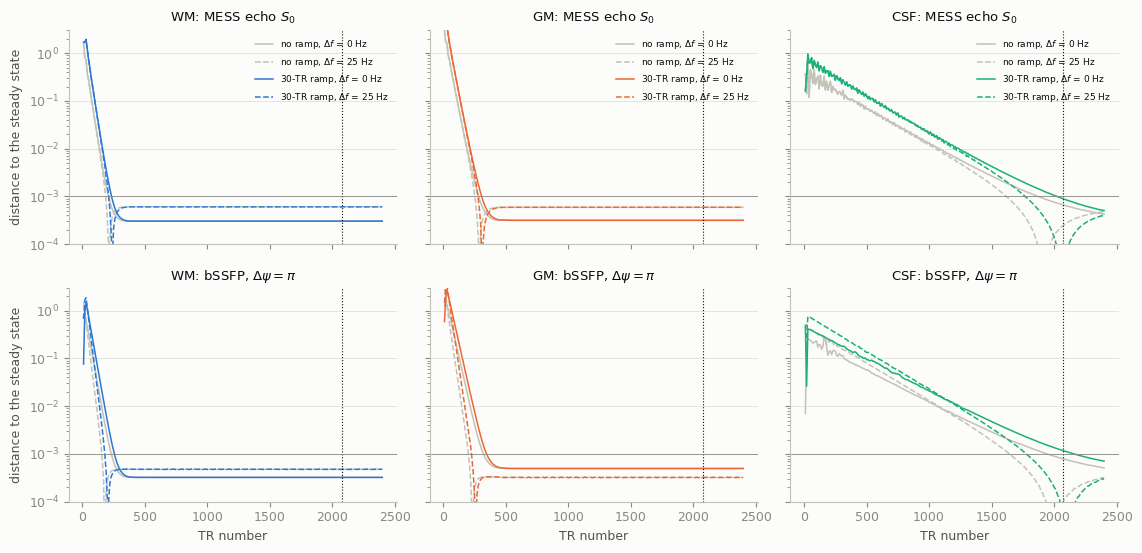

In [3]:
N_DUMMY = 2000                                   # used by notebooks 3-5
centre_line = N_DUMMY + protocol.matrix[1] // 2  # TR that acquires the centre of k-space
fig, axes = plt.subplots(2, 3, figsize=(11.5, 5.6), sharex=True, sharey=True)
for c, name in enumerate(("WM", "GM", "CSF")):
    for r, kind in enumerate(("MESS", "bSSFP")):
        ax = axes[r, c]
        for ramp, color in ((0, plotting.AXIS), (RAMP, plotting.TISSUE_COLORS[name])):
            for i, ls in enumerate(("-", "--")):
                label = (f"{'no ramp' if ramp == 0 else f'{RAMP}-TR ramp'}, "
                         f"$\\Delta f$ = {offsets[i]:.0f} Hz")
                ax.semilogy(trs, distance[name, kind, ramp][i], color=color, ls=ls, lw=1.1, label=label)
        ax.axvline(centre_line, color=plotting.INK, lw=0.8, ls=":")
        ax.axhline(1e-3, color=plotting.MUTED, lw=0.6)
        ax.set_ylim(1e-4, 3)
        ax.grid(True, axis="y")
        signal_name = "MESS echo $S_0$" if kind == "MESS" else "bSSFP, $\\Delta\\psi=\\pi$"
        ax.set_title(f"{name}: {signal_name}")
        if r == 1:
            ax.set_xlabel("TR number")
        if c == 0:
            ax.set_ylabel("distance to the steady state")
        if r == 0:
            ax.legend(fontsize=6.5, loc="upper right")
fig.tight_layout()
plt.show()

Grey: no ramp; colour: 30-TR linear ramp. The dotted line is the TR that acquires the centre of
k-space after 2000 dummies; the horizontal line marks 0.1 %. Off resonance the curves level off at
a few $10^{-3}$: an isolated voxel is displaced by a small fraction of a pixel along the readout,
which lowers its reconstructed peak slightly. The number of TRs to get within 1 % and 0.1 % of the
steady state (on resonance), and the time constant of the slow approach:

In [4]:
def first_below(curve, tol):
    above = np.nonzero(curve >= tol)[0]
    return trs[0] if above.size == 0 else (trs[above[-1] + 1] if above[-1] + 1 < trs.size else None)

print("tissue  sequence   1/lambda   fitted     TRs to 1 %           TRs to 0.1 %")
print("                     [TR]      [TR]    no ramp  ramp      no ramp  ramp")
for name in ("WM", "GM", "CSF"):
    _, t1, t2, _ = sim.TABLE_S1[name]
    lam_tr = 1 / (np.cos(alpha / 2) ** 2 / t1 + np.sin(alpha / 2) ** 2 / t2) / protocol.tr
    for kind in ("MESS", "bSSFP"):
        d0, dr = distance[name, kind, 0][0], distance[name, kind, RAMP][0]
        fit = (d0 < 5e-2) & (d0 > 2e-3) & (trs > 60)
        tau = -1 / np.polyfit(trs[fit], np.log(d0[fit]), 1)[0]
        print(f"{name:6s}  {kind:8s} {lam_tr:8.0f} {tau:9.0f} {first_below(d0, 1e-2)!s:>10} "
              f"{first_below(dr, 1e-2)!s:>5} {first_below(d0, 1e-3)!s:>12} {first_below(dr, 1e-3)!s:>5}")

tissue  sequence   1/lambda   fitted     TRs to 1 %           TRs to 0.1 %
                     [TR]      [TR]    no ramp  ramp      no ramp  ramp
WM      MESS           30        28        140   170          210   240
WM      bSSFP          30        31        160   180          240   260
GM      MESS           37        36        200   220          290   310
GM      bSSFP          37        40        220   250          330   350
CSF     MESS          326       310       1090  1240         1880  2030
CSF     bSSFP         326       339       1070  1250         1950  2160


**What the ramp does, and does not do.** The ramp damps the oscillation at the start (compare the
grey and coloured curves over the first few hundred TRs), but it does not bring the steady state
closer: the curves decay with the same time constant, close to $1/\lambda$, and the ramp adds its own
length. It also turns all of the initial excess magnetisation into the slow component, where
without a ramp part of it goes into the faster-damped oscillation. For WM and GM the steady state
is reached within a few hundred TRs either way; for CSF only time helps, and nothing short of
roughly 2000 TRs brings every echo within 0.1 %.

Notebooks 3–5 therefore play **2000 dummy TRs** (20 s) without a ramp before every simulated
acquisition. For a real single-slice scan in which fluid does not matter, a few hundred dummies are
enough for WM and GM. A 3D scan needs no extra dummies: with 150 × 75 encoding steps the centre of
k-space is reached after 5 600 TRs, about 55 s into the scan.

**Next:** [notebook 3](03_echo_orders.ipynb) looks at the MESS echoes themselves.